# ChemAI: прогнозирование IC50, CC50 и SI

Цель работы — построить регрессионную модель для прогнозирования трёх целевых показателей: `IC50`, `CC50` и `SI`.

В работе используются числовые молекулярные дескрипторы из файлов `train.csv` и `test.csv`.  
Итоговый результат сохраняется в формате `submission.csv` с колонками `index`, `IC50`, `CC50`, `SI`.

Основной подход:
- первичная проверка структуры данных;
- обработка пропусков внутри ML-пайплайнов;
- сравнение нескольких моделей на кросс-валидации;
- построение финального ансамбля;
- формирование итогового файла для отправки на Kaggle.

In [5]:
# Установка CatBoost

import importlib.util
import subprocess
import sys

if importlib.util.find_spec("catboost") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "catboost"])

In [6]:
# Импорты

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline

In [7]:
# Глобальные настройки

DATA_DIR = Path("/content")

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SAMPLE_SUBMISSION_PATH = DATA_DIR / "sample_submission.csv"

RANDOM_STATE = 42
N_SPLITS = 5

ID_COL = "index"
TARGET_COLS = ["IC50, mM", "CC50, mM", "SI"]
SUBMISSION_COLS = ["IC50", "CC50", "SI"]

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 120)

In [8]:
# Проверка наличия исходных файлов

required_paths = {
    "train.csv": TRAIN_PATH,
    "test.csv": TEST_PATH,
    "sample_submission.csv": SAMPLE_SUBMISSION_PATH,
}

for file_name, file_path in required_paths.items():
    if not file_path.exists():
        raise FileNotFoundError(f"Файл {file_name} не найден по пути {file_path}")

print("Все исходные файлы найдены.")

Все исходные файлы найдены.


### Вывод

В начале ноутбука собраны все основные настройки, пути к данным и импорты.  
Файлы `train.csv`, `test.csv` и `sample_submission.csv` ожидаются в локальной области Google Colab `/content`.  


In [9]:
# Загрузка данных

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

data_shapes = pd.DataFrame({
    "dataset": ["train", "test", "sample_submission"],
    "rows": [train.shape[0], test.shape[0], sample_submission.shape[0]],
    "columns": [train.shape[1], test.shape[1], sample_submission.shape[1]],
})

display(data_shapes)

,dataset,rows,columns
0,train,751,214
1,test,250,211
2,sample_submission,250,4


In [10]:
# Первичный просмотр данных

display(train.head(3))
display(test.head(3))
display(sample_submission.head(3))

,index,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,...,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,195.287,182.183,195.071785,70,0,0.119177,-0.360247,0.360247,0.119177,1.230769,2.076923,2.923077,32.166506,10.291948,2.082825,-2.203512,2.178787,-2.230562,7.988993,0.155539,2.471240,2.063714,244.361475,8.932875,7.478889,8.295385,6.466326,4.421446,5.576147,2.950079,4.024775,1.987598,2.937188,1.292489,2.101284,-0.67,1789.177854,8.907639,4.533756,2.386264,82.881829,9.636773,6.730817,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,360.907,335.707,360.127441,130,0,0.237676,-0.393087,0.393087,0.237676,1.304348,1.956522,2.521739,35.495692,9.631497,2.400142,-2.449813,2.456783,-2.415599,7.887726,-0.003171,2.314947,2.157249,690.565805,17.466255,13.765101,15.337527,10.385377,7.640209,9.564493,7.787893,9.785752,4.341084,5.452070,3.857712,4.739970,-0.82,54482.266038,18.517681,6.239496,5.075681,142.823022,10.423316,0.000000,0.000000,10.023291,0.0,0.0,0.0,13.556771,0.0,...,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,315.457,286.225,315.219829,126,0,0.160487,-0.492870,0.492870,0.160487,1.173913,1.956522,2.608696,16.507764,9.486685,2.502184,-2.562182,2.584438,-2.491154,5.425001,-0.007335,2.579710,1.480238,591.304512,16.449383,14.816132,14.816132,11.057210,8.664686,8.664686,7.437432,7.437432,5.950196,5.950196,4.178057,4.178057,-1.48,168844.584418,16.380319,6.561383,3.116782,139.616280,14.790515,0.000000,11.499024,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,index,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,...,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,13.761882,13.761882,0.121946,-0.962625,0.770057,30.580645,450.541,432.397,450.070799,156,0,0.307795,-0.480983,0.480983,0.307795,1.129032,1.967742,2.741935,32.166547,9.704289,2.608086,-2.425359,2.544663,-2.545620,8.056645,-0.147725,3.494848,1.531269,1171.998965,21.275292,16.250243,17.883236,15.058551,10.093357,11.852663,8.159777,10.171294,6.660754,8.495535,5.422732,7.148420,-2.84,2.734932e+07,18.891356,6.831720,2.610159,186.392155,10.006437,6.165776,0.000000,5.907180,5.90718,5.969305,19.283521,0.0,0.0,23.098671,30.351141,33.892353,...,0,2,2,0,1,0,0,0,0,1,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
1,1,13.224489,13.224489,0.066132,-1.801871,0.278628,25.687500,448.380,428.220,448.100561,170,0,0.238633,-0.507966,0.507966,0.238633,0.906250,1.593750,2.250000,16.707906,9.991346,2.450224,-2.390353,2.369524,-2.597794,5.878314,-0.277225,2.752143,1.885708,1185.055548,23.153972,16.321448,16.321448,15.205616,9.502898,9.502898,7.289468,7.289468,5.129606,5.129606,3.459029,3.459029,-3.35,1.303530e+07,21.865906,8.297053,3.720411,179.107049,49.636569,52.633645,5.760247,17.468329,0.00000,0.000000,4.794537,0.0,0.0,0.000000,0.000000,24.265468,...,0,0,0,0,0,0,0,0,0,2,0,1,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2,6.191528,6.191528,0.445278,0.445278,0.657472,55.384615,179.307,158.139,179.167400,74,0,0.006729,-0.327440,0.327440,0.006729,1.000000,1.384615,1.692308,14.717158,9.477838,2.516654,-2.580818,2.603245,-2.529164,5.037930,-0.063729,2.001545,1.911265,183.880154,9.052042,8.629392,8.629392,6.178270,5.934254,5.934254,6.068603,6.068603,5.051530,5.051530,4.735311,4.735311,-0.04,1.242959e+03,8.283315,2.502526,1.092133,81.076012,5.733667,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,68.617376,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,index,IC50,CC50,SI
0,0,0.723678,0.426328,0.308486
1,1,0.804617,0.643166,0.179750
2,2,0.907425,0.518521,0.298384


In [11]:
# Проверка структуры данных

feature_cols = [col for col in train.columns if col not in TARGET_COLS + [ID_COL]]

train_feature_set = set(feature_cols)
test_feature_set = set(test.columns) - {ID_COL}

missing_targets = [col for col in TARGET_COLS if col not in train.columns]
missing_features_in_test = sorted(train_feature_set - test_feature_set)
extra_features_in_test = sorted(test_feature_set - train_feature_set)

structure_check = pd.DataFrame({
    "check": [
        "ID column in train",
        "ID column in test",
        "ID column in sample_submission",
        "All target columns in train",
        "Number of feature columns",
        "Features missing in test",
        "Extra features in test",
    ],
    "result": [
        ID_COL in train.columns,
        ID_COL in test.columns,
        ID_COL in sample_submission.columns,
        len(missing_targets) == 0,
        len(feature_cols),
        len(missing_features_in_test),
        len(extra_features_in_test),
    ],
})

display(structure_check)

assert ID_COL in train.columns
assert ID_COL in test.columns
assert ID_COL in sample_submission.columns
assert len(missing_targets) == 0
assert len(missing_features_in_test) == 0
assert len(extra_features_in_test) == 0

,check,result
0,ID column in train,True
1,ID column in test,True
2,ID column in sample_submission,True
3,All target columns in train,True
4,Number of feature columns,210
5,Features missing in test,0
6,Extra features in test,0


In [12]:
# Проверка пропусков, дубликатов и типов данных

diagnostics = pd.DataFrame({
    "metric": [
        "Missing values in train",
        "Missing values in test",
        "Missing values in sample_submission",
        "Duplicated rows in train",
        "Duplicated rows in test",
        "Duplicated index in train",
        "Duplicated index in test",
        "Non-numeric feature columns",
    ],
    "value": [
        int(train.isna().sum().sum()),
        int(test.isna().sum().sum()),
        int(sample_submission.isna().sum().sum()),
        int(train.duplicated().sum()),
        int(test.duplicated().sum()),
        int(train[ID_COL].duplicated().sum()),
        int(test[ID_COL].duplicated().sum()),
        len(train[feature_cols].select_dtypes(exclude=["number"]).columns),
    ],
})

display(diagnostics)

missing_columns = pd.DataFrame({
    "train_missing": train[feature_cols].isna().sum(),
    "test_missing": test[feature_cols].isna().sum(),
})

missing_columns = missing_columns[
    (missing_columns["train_missing"] > 0)
    | (missing_columns["test_missing"] > 0)
].sort_values(["train_missing", "test_missing"], ascending=False)

display(missing_columns)

,metric,value
0,Missing values in train,24
1,Missing values in test,12
2,Missing values in sample_submission,0
3,Duplicated rows in train,0
4,Duplicated rows in test,0
5,Duplicated index in train,0
6,Duplicated index in test,0
7,Non-numeric feature columns,0


,train_missing,test_missing
MaxPartialCharge,2,1
MinPartialCharge,2,1
MaxAbsPartialCharge,2,1
MinAbsPartialCharge,2,1
BCUT2D_MWHI,2,1
BCUT2D_MWLOW,2,1
BCUT2D_CHGHI,2,1
BCUT2D_CHGLO,2,1
BCUT2D_LOGPHI,2,1
BCUT2D_LOGPLOW,2,1


In [13]:
# Описательная статистика целевых переменных

target_stats = train[TARGET_COLS].describe()
display(target_stats)

,"IC50, mM","CC50, mM",SI
count,751.000000,751.000000,751.000000
mean,204.544021,577.426098,89.153313
std,370.367937,641.515163,788.882198
min,0.003517,0.700808,0.011489
25%,13.222351,99.998894,1.500000
50%,44.069306,376.580899,4.000000
75%,206.787402,877.508784,17.372463
max,4095.188563,4538.976189,15620.600000


### Вывод

Обучающая выборка содержит 751 объект и 214 столбцов, тестовая выборка — 250 объектов и 211 столбцов.  
В обучающей выборке присутствуют три целевые переменные: `IC50, mM`, `CC50, mM` и `SI`.

Наборы признаков в `train` и `test` совпадают. Все признаки являются числовыми, поэтому дополнительное кодирование категориальных переменных не требуется.

В данных есть небольшое количество пропусков в молекулярных дескрипторах. Удалять строки нецелесообразно, поэтому далее пропуски будут обрабатываться внутри ML-пайплайнов с помощью медианной импутации.

Целевые переменные имеют разный масштаб и выраженные выбросы, особенно `SI`. Это нужно учитывать при выборе модели и оценке качества.

In [14]:
# Анализ связи между целевыми переменными

targets = train[TARGET_COLS].copy()

si_from_ratio = train["CC50, mM"] / train["IC50, mM"]
si_abs_diff = (train["SI"] - si_from_ratio).abs()

target_summary = pd.DataFrame({
    "metric": [
        "Non-positive IC50 values",
        "Non-positive CC50 values",
        "Non-positive SI values",
        "Mean absolute difference: SI vs CC50 / IC50",
        "Max absolute difference: SI vs CC50 / IC50",
    ],
    "value": [
        int((train["IC50, mM"] <= 0).sum()),
        int((train["CC50, mM"] <= 0).sum()),
        int((train["SI"] <= 0).sum()),
        si_abs_diff.mean(),
        si_abs_diff.max(),
    ],
})

display(target_summary)

target_corr = targets.corr()
display(target_corr)

,metric,value
0,Non-positive IC50 values,0.000000e+00
1,Non-positive CC50 values,0.000000e+00
2,Non-positive SI values,0.000000e+00
3,Mean absolute difference: SI vs CC50 / IC50,5.927787e-14
4,Max absolute difference: SI vs CC50 / IC50,2.000888e-11


,"IC50, mM","CC50, mM",SI
"IC50, mM",1.000000,0.470444,-0.060518
"CC50, mM",0.470444,1.000000,-0.005702
SI,-0.060518,-0.005702,1.000000


In [15]:
# Квантили целевых переменных

target_quantiles = targets.quantile([0.00, 0.05, 0.25, 0.50, 0.75, 0.95, 1.00]).T
target_quantiles.columns = ["min", "q05", "q25", "median", "q75", "q95", "max"]

display(target_quantiles)

,min,q05,q25,median,q75,q95,max
"IC50, mM",0.003517,1.329394,13.222351,44.069306,206.787402,1002.304418,4095.188563
"CC50, mM",0.700808,9.834099,99.998894,376.580899,877.508784,1883.480370,4538.976189
SI,0.011489,0.941805,1.500000,4.000000,17.372463,138.433453,15620.600000


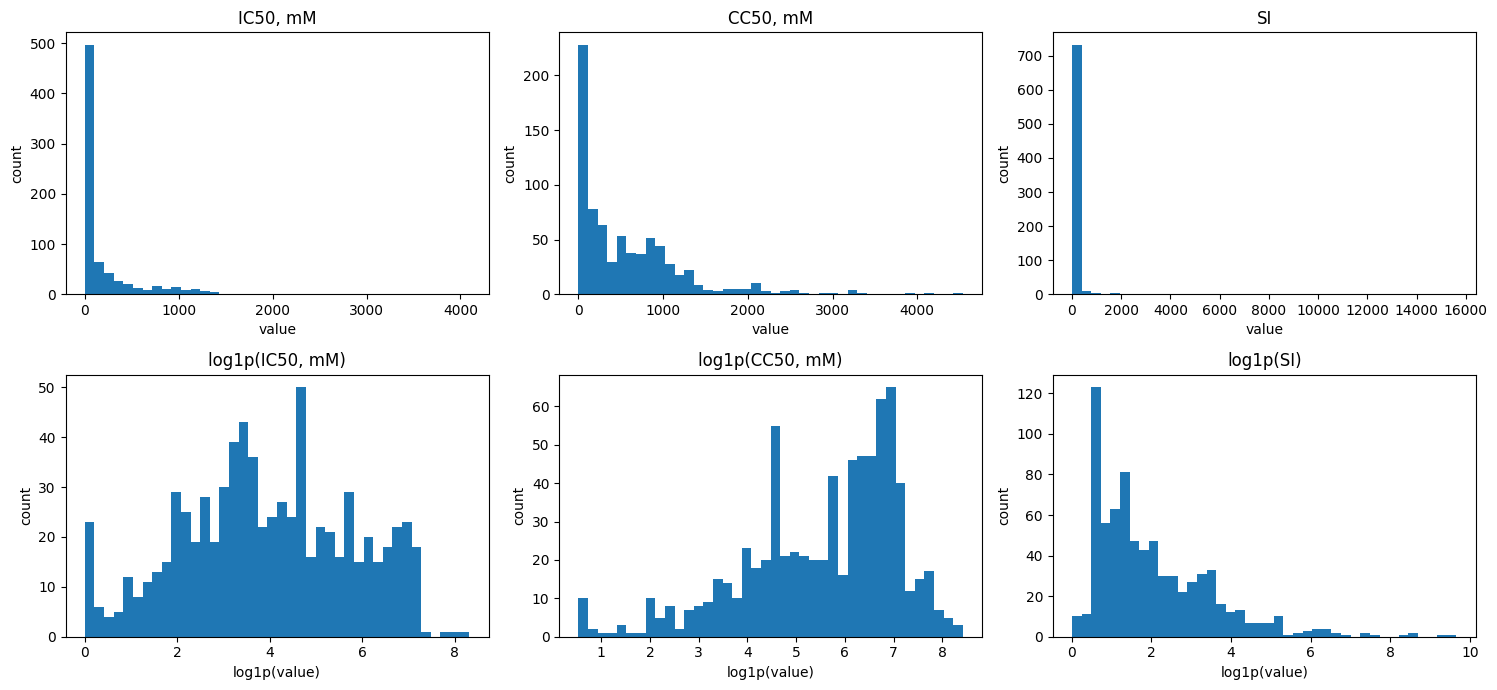

In [16]:
# Распределения целевых переменных до и после log1p-преобразования

fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for col_idx, col in enumerate(TARGET_COLS):
    axes[0, col_idx].hist(train[col], bins=40)
    axes[0, col_idx].set_title(col)
    axes[0, col_idx].set_xlabel("value")
    axes[0, col_idx].set_ylabel("count")

    axes[1, col_idx].hist(np.log1p(train[col]), bins=40)
    axes[1, col_idx].set_title(f"log1p({col})")
    axes[1, col_idx].set_xlabel("log1p(value)")
    axes[1, col_idx].set_ylabel("count")

plt.tight_layout()
plt.show()

### Вывод

Целевые переменные имеют положительные значения, поэтому для них допустимо использовать `log1p`-преобразование при проверке моделей.

Переменная `SI` практически полностью совпадает с отношением `CC50 / IC50`. Тем не менее в итоговом файле требуется предсказывать все три колонки, поэтому далее будут проверяться как прямое предсказание `SI`, так и постобработка через отношение предсказанных `CC50` и `IC50`.

Распределения таргетов сильно скошены вправо. Особенно выраженные выбросы наблюдаются у `SI`. После `log1p`-преобразования распределения становятся более компактными, поэтому модели на исходных и логарифмированных таргетах нужно сравнивать на кросс-валидации.

In [17]:
# Матрицы признаков и целевых переменных

X = train[feature_cols].copy()
y = train[TARGET_COLS].copy()
X_test = test[feature_cols].copy()

print("X:", X.shape)
print("y:", y.shape)
print("X_test:", X_test.shape)

X: (751, 210)
y: (751, 3)
X_test: (250, 210)


In [18]:
# Функции для оценки качества моделей

def rmse_by_target(y_true, y_pred, target_cols=TARGET_COLS):
    """Возвращает RMSE по каждому таргету и среднее значение по всем таргетам."""
    scores = {}

    for target_idx, target_col in enumerate(target_cols):
        mse = mean_squared_error(y_true.iloc[:, target_idx], y_pred[:, target_idx])
        scores[target_col] = np.sqrt(mse)

    scores["mean_RMSE"] = np.mean([scores[col] for col in target_cols])
    return scores


def evaluate_model_oof(model_name, model, X, y, use_log_target=False):
    """Оценивает модель на KFold и возвращает OOF-предсказания."""
    cv = KFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    oof_pred = np.zeros((len(y), len(TARGET_COLS)))
    fold_results = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X), start=1):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        current_model = clone(model)

        if use_log_target:
            y_train_fit = np.log1p(y_train)
        else:
            y_train_fit = y_train

        current_model.fit(X_train, y_train_fit)
        valid_pred = current_model.predict(X_valid)

        if use_log_target:
            valid_pred = np.expm1(valid_pred)

        valid_pred = np.clip(valid_pred, 0, None)
        oof_pred[valid_idx] = valid_pred

        fold_score = rmse_by_target(y_valid, valid_pred)
        fold_score["model"] = model_name
        fold_score["fold"] = fold
        fold_score["use_log_target"] = use_log_target

        fold_results.append(fold_score)

    fold_results = pd.DataFrame(fold_results)

    full_score = rmse_by_target(y, oof_pred)
    summary = {
        "model": model_name,
        "use_log_target": use_log_target,
        "IC50_RMSE": full_score["IC50, mM"],
        "CC50_RMSE": full_score["CC50, mM"],
        "SI_RMSE": full_score["SI"],
        "mean_RMSE": full_score["mean_RMSE"],
    }

    return oof_pred, fold_results, summary

In [19]:
# Базовые модели для сравнения

models_to_evaluate = [
    (
        "Dummy_median",
        Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", DummyRegressor(strategy="median")),
        ]),
        False,
    ),
    (
        "RandomForest_raw",
        Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(
                n_estimators=500,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                max_features="sqrt",
                min_samples_leaf=2,
            )),
        ]),
        False,
    ),
    (
        "ExtraTrees_raw",
        Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", ExtraTreesRegressor(
                n_estimators=500,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                max_features="sqrt",
                min_samples_leaf=2,
            )),
        ]),
        False,
    ),
    (
        "HistGradientBoosting_log1p",
        Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", MultiOutputRegressor(
                HistGradientBoostingRegressor(
                    max_iter=300,
                    learning_rate=0.03,
                    l2_regularization=0.1,
                    random_state=RANDOM_STATE,
                ),
                n_jobs=-1,
            )),
        ]),
        True,
    ),
    (
        "CatBoost_MultiRMSE_raw",
        Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", CatBoostRegressor(
                loss_function="MultiRMSE",
                iterations=800,
                learning_rate=0.03,
                depth=4,
                l2_leaf_reg=10,
                random_seed=RANDOM_STATE,
                verbose=False,
                allow_writing_files=False,
                thread_count=-1,
            )),
        ]),
        False,
    ),
]

In [20]:
# Кросс-валидационная оценка базовых моделей

oof_predictions = {}
all_fold_results = []
model_summaries = []

for model_name, model, use_log_target in models_to_evaluate:
    print(f"Evaluating: {model_name}")

    oof_pred, fold_results, summary = evaluate_model_oof(
        model_name=model_name,
        model=model,
        X=X,
        y=y,
        use_log_target=use_log_target,
    )

    oof_predictions[model_name] = oof_pred
    all_fold_results.append(fold_results)
    model_summaries.append(summary)

all_fold_results = pd.concat(all_fold_results, ignore_index=True)
model_summary = pd.DataFrame(model_summaries).sort_values("mean_RMSE").reset_index(drop=True)

display(model_summary)

Evaluating: Dummy_median
Evaluating: RandomForest_raw
Evaluating: ExtraTrees_raw
Evaluating: HistGradientBoosting_log1p
Evaluating: CatBoost_MultiRMSE_raw


,model,use_log_target,IC50_RMSE,CC50_RMSE,SI_RMSE,mean_RMSE
0,ExtraTrees_raw,False,317.598120,444.512131,795.063698,519.057983
1,RandomForest_raw,False,319.348363,447.473265,791.622802,519.481477
2,CatBoost_MultiRMSE_raw,False,321.196010,452.280802,795.695459,523.057424
3,HistGradientBoosting_log1p,True,338.369202,498.414165,778.481292,538.421553
4,Dummy_median,False,403.037954,673.090623,792.939863,623.022813


In [21]:
# Детализация результатов по fold

display(
    all_fold_results
    .sort_values(["model", "fold"])
    .reset_index(drop=True)
)

,"IC50, mM","CC50, mM",SI,mean_RMSE,model,fold,use_log_target
0,389.952584,431.549937,323.953749,381.818757,CatBoost_MultiRMSE_raw,1,False
1,244.344742,364.474373,531.875627,380.231581,CatBoost_MultiRMSE_raw,2,False
2,328.137551,444.157869,935.772038,569.355819,CatBoost_MultiRMSE_raw,3,False
3,301.079597,531.047328,266.501684,366.209536,CatBoost_MultiRMSE_raw,4,False
4,324.681174,473.864300,1354.491560,717.679011,CatBoost_MultiRMSE_raw,5,False
5,466.000699,608.331828,174.683702,416.338743,Dummy_median,1,False
6,288.786240,624.086643,410.021842,440.964909,Dummy_median,2,False
7,422.323458,661.761223,984.156999,689.413893,Dummy_median,3,False
8,390.947038,735.787790,94.824743,407.186524,Dummy_median,4,False
9,424.361105,725.909645,1404.125120,851.465290,Dummy_median,5,False


### Вывод

Для оценки качества использована 5-fold кросс-валидация с перемешиванием и фиксированным `random_state`.

Пропуски обрабатываются внутри пайплайнов с помощью медианной импутации. Это важно, так как преобразования выполняются только на обучающей части каждого fold и не используют данные валидации.

Наивная модель `DummyRegressor` используется как baseline. Основные рабочие модели — ансамбли деревьев и градиентный бустинг.

По результатам кросс-валидации модели `ExtraTrees`, `RandomForest`, `HistGradientBoosting` и `CatBoost` дают существенно лучшее качество, чем наивный baseline. Дальше эти модели используются для построения ансамбля.

In [22]:
# Постобработка предсказаний SI

SI_CLIP_MAX = train["SI"].max()


def apply_si_ratio(pred, eps=1e-6, si_clip_max=None):
    """Заменяет SI на отношение предсказанных CC50 и IC50."""
    corrected_pred = pred.copy()

    ic50_pred = np.clip(corrected_pred[:, 0], eps, None)
    cc50_pred = np.clip(corrected_pred[:, 1], 0, None)

    si_ratio = cc50_pred / ic50_pred

    if si_clip_max is not None:
        si_ratio = np.clip(si_ratio, 0, si_clip_max)

    corrected_pred[:, 2] = si_ratio
    return corrected_pred


def apply_si_blend(pred, alpha, eps=1e-6, si_clip_max=None):
    """
    Смешивает прямое предсказание SI и расчётное значение CC50 / IC50.

    alpha = 0: используется только прямое предсказание SI.
    alpha = 1: используется только отношение CC50 / IC50.
    """
    corrected_pred = pred.copy()

    ic50_pred = np.clip(corrected_pred[:, 0], eps, None)
    cc50_pred = np.clip(corrected_pred[:, 1], 0, None)

    si_direct = np.clip(corrected_pred[:, 2], 0, None)
    si_ratio = cc50_pred / ic50_pred

    if si_clip_max is not None:
        si_direct = np.clip(si_direct, 0, si_clip_max)
        si_ratio = np.clip(si_ratio, 0, si_clip_max)

    corrected_pred[:, 2] = (1 - alpha) * si_direct + alpha * si_ratio
    return corrected_pred

In [23]:
# Проверка стратегий для SI на OOF-предсказаниях

def evaluate_si_strategies(model_name, oof_pred, y):
    rows = []

    # Прямое предсказание SI
    direct_scores = rmse_by_target(y, oof_pred)
    rows.append({
        "model": model_name,
        "si_strategy": "direct",
        "alpha": 0.0,
        "IC50_RMSE": direct_scores["IC50, mM"],
        "CC50_RMSE": direct_scores["CC50, mM"],
        "SI_RMSE": direct_scores["SI"],
        "mean_RMSE": direct_scores["mean_RMSE"],
    })

    # Расчётное SI = CC50 / IC50
    ratio_pred = apply_si_ratio(
        oof_pred,
        si_clip_max=SI_CLIP_MAX,
    )

    ratio_scores = rmse_by_target(y, ratio_pred)
    rows.append({
        "model": model_name,
        "si_strategy": "ratio",
        "alpha": 1.0,
        "IC50_RMSE": ratio_scores["IC50, mM"],
        "CC50_RMSE": ratio_scores["CC50, mM"],
        "SI_RMSE": ratio_scores["SI"],
        "mean_RMSE": ratio_scores["mean_RMSE"],
    })

    # Смешанная стратегия
    for alpha in np.linspace(0.0, 1.0, 21):
        blend_pred = apply_si_blend(
            oof_pred,
            alpha=alpha,
            si_clip_max=SI_CLIP_MAX,
        )

        blend_scores = rmse_by_target(y, blend_pred)

        rows.append({
            "model": model_name,
            "si_strategy": "blend",
            "alpha": alpha,
            "IC50_RMSE": blend_scores["IC50, mM"],
            "CC50_RMSE": blend_scores["CC50, mM"],
            "SI_RMSE": blend_scores["SI"],
            "mean_RMSE": blend_scores["mean_RMSE"],
        })

    return pd.DataFrame(rows)


si_strategy_results = []

models_for_si_check = [
    "RandomForest_raw",
    "ExtraTrees_raw",
    "HistGradientBoosting_log1p",
    "CatBoost_MultiRMSE_raw",
]

for model_name in models_for_si_check:
    if model_name in oof_predictions:
        si_strategy_results.append(
            evaluate_si_strategies(
                model_name=model_name,
                oof_pred=oof_predictions[model_name],
                y=y,
            )
        )

si_strategy_results = pd.concat(si_strategy_results, ignore_index=True)

best_si_strategy_by_model = (
    si_strategy_results
    .sort_values("mean_RMSE")
    .groupby("model", as_index=False)
    .first()
    .sort_values("mean_RMSE")
    .reset_index(drop=True)
)

display(best_si_strategy_by_model)

,model,si_strategy,alpha,IC50_RMSE,CC50_RMSE,SI_RMSE,mean_RMSE
0,ExtraTrees_raw,blend,0.5,317.598120,444.512131,770.253365,510.787872
1,RandomForest_raw,blend,0.5,319.348363,447.473265,770.970688,512.597439
2,CatBoost_MultiRMSE_raw,direct,0.0,321.196010,452.280802,795.695459,523.057424
3,HistGradientBoosting_log1p,direct,0.0,338.369202,498.414165,778.481292,538.421553


In [24]:
# Лучшие варианты стратегии SI

display(
    si_strategy_results
    .sort_values("mean_RMSE")
    .head(15)
    .reset_index(drop=True)
)

,model,si_strategy,alpha,IC50_RMSE,CC50_RMSE,SI_RMSE,mean_RMSE
0,ExtraTrees_raw,blend,0.50,317.598120,444.512131,770.253365,510.787872
1,ExtraTrees_raw,blend,0.55,317.598120,444.512131,770.285451,510.798568
2,ExtraTrees_raw,blend,0.45,317.598120,444.512131,770.685352,510.931868
3,ExtraTrees_raw,blend,0.60,317.598120,444.512131,770.781555,510.963935
4,ExtraTrees_raw,blend,0.40,317.598120,444.512131,771.580634,511.230295
5,ExtraTrees_raw,blend,0.65,317.598120,444.512131,771.740780,511.283677
6,ExtraTrees_raw,blend,0.35,317.598120,444.512131,772.937601,511.682618
7,ExtraTrees_raw,blend,0.70,317.598120,444.512131,773.161402,511.757218
8,ExtraTrees_raw,blend,0.30,317.598120,444.512131,774.753828,512.288026
9,ExtraTrees_raw,blend,0.75,317.598120,444.512131,775.040885,512.383712


### Вывод

Проверены три способа получения `SI`: прямое предсказание моделью, расчёт через отношение `CC50 / IC50` и смешанная стратегия.

Прямое предсказание `SI` не всегда является оптимальным, так как `SI` математически связан с двумя другими таргетами. В то же время полный переход к формуле `CC50 / IC50` также может быть нестабильным, потому что ошибка в `IC50` при делении усиливает ошибку в `SI`.

Поэтому в дальнейшем для ансамбля используется смешанная стратегия: часть значения `SI` берётся из прямого предсказания модели, часть — из отношения предсказанных `CC50` и `IC50`.

Функция `apply_si_blend()` будет использоваться при построении финального ансамбля.

In [25]:
# Модели финального ансамбля

def build_final_models(random_state=RANDOM_STATE):
    """Создаёт модели, используемые в финальном ансамбле."""
    extra_trees_model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(
            n_estimators=500,
            random_state=random_state,
            n_jobs=-1,
            max_features="sqrt",
            min_samples_leaf=2,
        )),
    ])

    hist_gb_model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", MultiOutputRegressor(
            HistGradientBoostingRegressor(
                max_iter=300,
                learning_rate=0.03,
                l2_regularization=0.1,
                random_state=random_state,
            ),
            n_jobs=-1,
        )),
    ])

    catboost_model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", CatBoostRegressor(
            loss_function="MultiRMSE",
            iterations=800,
            learning_rate=0.03,
            depth=4,
            l2_leaf_reg=10,
            random_seed=random_state,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
        )),
    ])

    return extra_trees_model, hist_gb_model, catboost_model

In [26]:
# OOF-оценка финального ансамбля

def evaluate_final_ensemble_oof(X, y):
    cv = KFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    oof_pred = np.zeros((len(y), len(TARGET_COLS)))
    fold_results = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X), start=1):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        extra_trees_model, hist_gb_model, catboost_model = build_final_models(
            random_state=RANDOM_STATE,
        )

        extra_trees_model.fit(X_train, y_train)
        pred_extra_trees = extra_trees_model.predict(X_valid)
        pred_extra_trees = np.clip(pred_extra_trees, 0, None)

        hist_gb_model.fit(X_train, np.log1p(y_train))
        pred_hist_gb = np.expm1(hist_gb_model.predict(X_valid))
        pred_hist_gb = np.clip(pred_hist_gb, 0, None)

        catboost_model.fit(X_train, y_train)
        pred_catboost = catboost_model.predict(X_valid)
        pred_catboost = np.asarray(pred_catboost)
        pred_catboost = np.clip(pred_catboost, 0, None)

        fold_pred = (
            0.60 * pred_extra_trees
            + 0.10 * pred_hist_gb
            + 0.30 * pred_catboost
        )

        fold_pred = apply_si_blend(
            fold_pred,
            alpha=0.45,
            si_clip_max=SI_CLIP_MAX,
        )

        fold_pred = np.clip(fold_pred, 0, None)
        oof_pred[valid_idx] = fold_pred

        fold_score = rmse_by_target(y_valid, fold_pred)
        fold_score["fold"] = fold
        fold_results.append(fold_score)

    fold_results = pd.DataFrame(fold_results)

    final_score = rmse_by_target(y, oof_pred)
    final_summary = pd.DataFrame([{
        "IC50_RMSE": final_score["IC50, mM"],
        "CC50_RMSE": final_score["CC50, mM"],
        "SI_RMSE": final_score["SI"],
        "mean_RMSE": final_score["mean_RMSE"],
    }])

    return oof_pred, fold_results, final_summary


final_oof_pred, final_fold_results, final_cv_summary = evaluate_final_ensemble_oof(X, y)

display(final_cv_summary)
display(final_fold_results)

,IC50_RMSE,CC50_RMSE,SI_RMSE,mean_RMSE
0,315.432876,441.783044,770.514836,509.243585


,"IC50, mM","CC50, mM",SI,mean_RMSE,fold
0,386.169561,426.831985,187.690706,333.564084,1
1,243.097778,330.687672,429.049635,334.278362,2
2,314.734169,417.042499,936.625996,556.134221,3
3,298.605463,531.297105,148.785609,326.229392,4
4,317.352103,477.710088,1361.422733,718.828308,5


In [27]:
# Сравнение финального ансамбля с одиночными моделями

final_model_row = final_cv_summary.copy()
final_model_row.insert(0, "model", "Final_ensemble")
final_model_row.insert(1, "use_log_target", "mixed")

comparison_table = pd.concat(
    [
        model_summary[["model", "use_log_target", "IC50_RMSE", "CC50_RMSE", "SI_RMSE", "mean_RMSE"]],
        final_model_row[["model", "use_log_target", "IC50_RMSE", "CC50_RMSE", "SI_RMSE", "mean_RMSE"]],
    ],
    ignore_index=True,
)

comparison_table = comparison_table.sort_values("mean_RMSE").reset_index(drop=True)
display(comparison_table)

,model,use_log_target,IC50_RMSE,CC50_RMSE,SI_RMSE,mean_RMSE
0,Final_ensemble,mixed,315.432876,441.783044,770.514836,509.243585
1,ExtraTrees_raw,False,317.598120,444.512131,795.063698,519.057983
2,RandomForest_raw,False,319.348363,447.473265,791.622802,519.481477
3,CatBoost_MultiRMSE_raw,False,321.196010,452.280802,795.695459,523.057424
4,HistGradientBoosting_log1p,True,338.369202,498.414165,778.481292,538.421553
5,Dummy_median,False,403.037954,673.090623,792.939863,623.022813


### Вывод

Финальная модель построена как взвешенный ансамбль трёх моделей:

- `ExtraTreesRegressor` на исходных таргетах;
- `HistGradientBoostingRegressor` на `log1p`-преобразованных таргетах;
- `CatBoostRegressor` с функцией потерь `MultiRMSE`.

Веса ансамбля выбраны по результатам кросс-валидационных экспериментов: `0.60`, `0.10` и `0.30` соответственно.

Для `SI` используется смешанная стратегия: 55% прямого предсказания ансамбля и 45% расчётного значения `CC50 / IC50`. Такой вариант учитывает математическую связь между таргетами, но не полностью зависит от отношения двух предсказанных величин.

Финальный ансамбль показывает лучшее качество среди сохранённых в ноутбуке моделей и используется для формирования итогового submission-файла.

## Шаг 7. Обучение финального ансамбля на всей обучающей выборке

На предыдущем шаге финальный ансамбль был проверен на кросс-валидации.  
Теперь те же модели обучаются на всей обучающей выборке, после чего используются для прогнозирования тестовых объектов.

В финальном ансамбле используются:
- `ExtraTreesRegressor` на исходных таргетах;
- `HistGradientBoostingRegressor` на `log1p`-преобразованных таргетах;
- `CatBoostRegressor` с функцией потерь `MultiRMSE`.

Все преобразования признаков выполняются внутри `Pipeline`, чтобы одинаково применяться при обучении и прогнозировании.

In [28]:
# Обучение финальных моделей на всей обучающей выборке

final_extra_trees, final_hist_gb, final_catboost = build_final_models(
    random_state=RANDOM_STATE
)

final_extra_trees.fit(X, y)

final_hist_gb.fit(X, np.log1p(y))

final_catboost.fit(X, y)

print("Финальные модели обучены.")

Финальные модели обучены.


In [29]:
# Предсказания финального ансамбля для тестовой выборки

pred_extra_trees = final_extra_trees.predict(X_test)
pred_extra_trees = np.clip(pred_extra_trees, 0, None)

pred_hist_gb = final_hist_gb.predict(X_test)
pred_hist_gb = np.expm1(pred_hist_gb)
pred_hist_gb = np.clip(pred_hist_gb, 0, None)

pred_catboost = final_catboost.predict(X_test)
pred_catboost = np.asarray(pred_catboost)
pred_catboost = np.clip(pred_catboost, 0, None)

test_pred = (
    0.60 * pred_extra_trees
    + 0.10 * pred_hist_gb
    + 0.30 * pred_catboost
)

test_pred = apply_si_blend(
    test_pred,
    alpha=0.45,
    si_clip_max=SI_CLIP_MAX,
)

test_pred = np.clip(test_pred, 0, None)

test_pred_df = pd.DataFrame(
    test_pred,
    columns=SUBMISSION_COLS,
)

display(test_pred_df.describe())

,IC50,CC50,SI
count,250.000000,250.000000,250.000000
mean,241.952867,635.311216,42.939922
std,316.486079,510.517525,162.980777
min,4.400134,64.275679,1.195269
25%,70.062238,312.406211,6.534228
50%,138.976605,482.157277,11.570615
75%,297.097668,833.324499,24.162595
max,2428.074411,3198.940325,1345.520248


### Вывод

Финальные модели обучены на всей обучающей выборке.  
Предсказания для тестовой выборки получены как взвешенная сумма трёх моделей с последующей постобработкой `SI`.

Все предсказанные значения неотрицательны. Распределение прогнозов имеет широкий диапазон значений, что соответствует характеру целевых переменных в обучающей выборке.

## Шаг 8. Формирование итогового submission-файла

На этом шаге предсказания финального ансамбля приводятся к формату `sample_submission.csv`.

Итоговый файл должен содержать четыре колонки:
- `index`;
- `IC50`;
- `CC50`;
- `SI`.

Перед сохранением выполняется техническая проверка: размер таблицы, порядок колонок, отсутствие пропусков и отрицательных значений.

In [30]:
# Сборка итогового submission-файла

submission = sample_submission.copy()

submission["IC50"] = test_pred_df["IC50"].values
submission["CC50"] = test_pred_df["CC50"].values
submission["SI"] = test_pred_df["SI"].values

expected_columns = ["index", "IC50", "CC50", "SI"]

submission = submission[expected_columns]

display(submission.head())

,index,IC50,CC50,SI
0,0,127.477622,316.811551,7.855585
1,1,231.568068,382.126852,5.324445
2,2,53.026869,315.019000,6.689182
3,3,244.674704,435.955799,8.409130
4,4,186.100083,315.250644,4.145278


In [31]:
# Проверка итогового submission-файла

submission_checks = pd.DataFrame({
    "check": [
        "Number of rows matches test",
        "Columns are correct",
        "Missing values",
        "Negative IC50 predictions",
        "Negative CC50 predictions",
        "Negative SI predictions",
    ],
    "value": [
        submission.shape[0] == test.shape[0],
        submission.columns.tolist() == expected_columns,
        int(submission.isna().sum().sum()),
        int((submission["IC50"] < 0).sum()),
        int((submission["CC50"] < 0).sum()),
        int((submission["SI"] < 0).sum()),
    ],
})

display(submission_checks)

assert submission.shape[0] == test.shape[0]
assert submission.columns.tolist() == expected_columns
assert submission.isna().sum().sum() == 0
assert (submission[SUBMISSION_COLS] < 0).sum().sum() == 0

,check,value
0,Number of rows matches test,True
1,Columns are correct,True
2,Missing values,0
3,Negative IC50 predictions,0
4,Negative CC50 predictions,0
5,Negative SI predictions,0


In [32]:
# Описательная статистика итоговых предсказаний

display(submission[SUBMISSION_COLS].describe())

,IC50,CC50,SI
count,250.000000,250.000000,250.000000
mean,241.952867,635.311216,42.939922
std,316.486079,510.517525,162.980777
min,4.400134,64.275679,1.195269
25%,70.062238,312.406211,6.534228
50%,138.976605,482.157277,11.570615
75%,297.097668,833.324499,24.162595
max,2428.074411,3198.940325,1345.520248


In [33]:
# Сохранение итогового файла

OUTPUT_PATH = DATA_DIR / "submission.csv"

submission.to_csv(OUTPUT_PATH, index=False)

print(f"Файл сохранён: {OUTPUT_PATH}")
print(f"Размер файла, байт: {OUTPUT_PATH.stat().st_size}")

Файл сохранён: /content/submission.csv
Размер файла, байт: 14662


### Вывод

Итоговый файл `submission.csv` сформирован в формате `sample_submission.csv`.

Файл содержит 250 строк и четыре требуемые колонки: `index`, `IC50`, `CC50`, `SI`.  
Пропуски и отрицательные значения в предсказаниях отсутствуют.

Файл `submission.csv` готов для загрузки на Kaggle.

## Шаг 9. Журнал экспериментов и выбор финальной модели

В процессе работы были проверены несколько вариантов моделей и постобработки.  
В финальный ноутбук включён не весь черновой код экспериментов, а краткая сводка основных проверок, повлиявших на выбор итогового решения.

Основные критерии выбора:
- качество на кросс-валидации;
- результат на public leaderboard;
- устойчивость решения;
- отсутствие чрезмерной подгонки под отдельную отправку.

### Сводка основных экспериментов

| Версия / подход | Суть эксперимента | Результат | Решение |
|---|---|---:|---|
| Baseline | `DummyRegressor` с медианным прогнозом | Существенно хуже ML-моделей | Использован только как нижняя граница качества |
| Базовые модели | `RandomForest`, `ExtraTrees`, `HistGradientBoosting`, `CatBoost` | Дали заметное улучшение относительно baseline | Использованы как кандидаты для ансамбля |
| v1 | Ансамбль `ExtraTrees + RandomForest + HistGradientBoosting` | Public score `301.36854` | Сильная базовая версия |
| v2 | Target-wise ансамбль с разными весами по таргетам | Public score `301.63951` | Отклонён, public score ухудшился |
| v3 | Донастроенный глобальный ансамбль `ExtraTrees + HistGradientBoosting + CatBoost` | Public score `300.28797` | Выбран как финальная версия |
| v4 | Isotonic-калибровка предсказаний | Public score `306.33587` | Отклонена, сильное ухудшение |
| v5 | Усреднение нескольких random seed для архитектуры v3 | Public score `300.35762` | Почти равно v3, но немного хуже |
| v6 | Добавление KNN/similarity-модели к v3 | Public score `302.47473` | Отклонён, public score ухудшился |

### Обоснование финального выбора

Лучшей версией по public leaderboard стала версия `v3`, основанная на ансамбле:

- `ExtraTreesRegressor` — вес `0.60`;
- `HistGradientBoostingRegressor` на `log1p`-таргетах — вес `0.10`;
- `CatBoostRegressor` с `MultiRMSE` — вес `0.30`.

Для `SI` использована смешанная стратегия: часть значения берётся из прямого предсказания ансамбля, часть — из отношения предсказанных `CC50 / IC50`.

Дополнительные эксперименты показали, что более сложная постобработка не всегда улучшает качество.  
Например, isotonic-калибровка улучшала внутреннюю OOF-оценку, но резко ухудшила public score.  
Seed-ensemble и KNN-бленд также не превзошли `v3`.

Поэтому итоговым решением выбран не самый сложный, а наиболее устойчивый из проверенных вариантов.

### Замечание о leaderboard

Public leaderboard используется как внешний ориентир, но не является полной оценкой качества модели, так как рассчитывается только на части тестовой выборки.  
Поэтому дополнительные варианты не включались в итоговое решение, если они улучшали только внутреннюю оценку, но ухудшали public score.

## Шаг 10. Финальная проверка и итоговое решение

Итоговый файл для отправки — `submission.csv`.

В ходе экспериментов также проверялись дополнительные варианты: калибровка предсказаний, усреднение нескольких random seed и добавление KNN-модели. Эти варианты не были включены в финальное решение, так как не улучшили результат на public leaderboard.

Финальная модель оставлена в более устойчивом виде: взвешенный ансамбль `ExtraTreesRegressor`, `HistGradientBoostingRegressor` и `CatBoostRegressor`.

In [34]:
# Финальная сверка сохранённого файла

saved_submission = pd.read_csv(OUTPUT_PATH)

final_checks = pd.DataFrame({
    "check": [
        "Saved file exists",
        "Rows match test",
        "Columns match expected format",
        "No missing values",
        "No negative predictions",
    ],
    "result": [
        OUTPUT_PATH.exists(),
        saved_submission.shape[0] == test.shape[0],
        saved_submission.columns.tolist() == expected_columns,
        saved_submission.isna().sum().sum() == 0,
        (saved_submission[SUBMISSION_COLS] < 0).sum().sum() == 0,
    ],
})

display(final_checks)

assert OUTPUT_PATH.exists()
assert saved_submission.shape[0] == test.shape[0]
assert saved_submission.columns.tolist() == expected_columns
assert saved_submission.isna().sum().sum() == 0
assert (saved_submission[SUBMISSION_COLS] < 0).sum().sum() == 0

,check,result
0,Saved file exists,True
1,Rows match test,True
2,Columns match expected format,True
3,No missing values,True
4,No negative predictions,True


### Итог

Финальный файл `submission.csv` успешно создан и прошёл техническую проверку.

В итоговом решении используется взвешенный ансамбль трёх моделей:
- `ExtraTreesRegressor`;
- `HistGradientBoostingRegressor`;
- `CatBoostRegressor`.

Для переменной `SI` применена смешанная стратегия, учитывающая как прямое предсказание модели, так и связь `SI = CC50 / IC50`.

Итоговый файл готов к загрузке на Kaggle.
Полученный public score = `300.28797`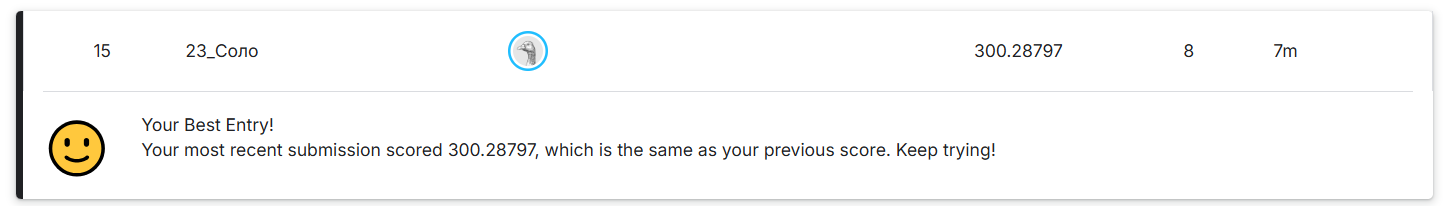